# Electrical Time Series Data Classification with TCN

## Prepare Notebook

In [1]:
import sys
from pathlib import Path

p = Path.cwd().resolve()
while p.name != "tinyml-timeseries" and p.parent != p:
    p = p.parent

REPO_ROOT = p
sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)
print("sys.path[0]:", sys.path[0])

REPO_ROOT: /Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries
sys.path[0]: /Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries


## Imports

In [2]:
import os
import numpy as np
import src.data.io as data_io
from src.data.split import stratified_split
from src.data.preprocessing import (
    clean_train_test,
    minmax_fit_transform_per_feature,
    one_hot_encode_labels,
)
from src.deployment.export import tflite_to_c_header
from src.evaluation.metrics import (
    evaluate_classification,
    plot_confusion_matrix
)
from src.deployment.export import export_tflite_int8
from src.deployment.inference import (
    load_tflite_model, 
    run_tflite_inference
)
from src.utils.visualization import plot_training_history
from tensorflow.keras.callbacks import (
    EarlyStopping, 
    ReduceLROnPlateau, 
    ModelCheckpoint
)
from tensorflow.keras.layers import (
    Input, 
    Conv1D, 
    Dense, 
    GlobalAveragePooling1D, 
    BatchNormalization, 
    Dropout, 
    Add
)
from tensorflow.keras.models import Model
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support, 
    classification_report
)

## Data Preparation

### Data Loading

In [3]:
ed_data, ed_labels = data_io.load_data_sliding()

X_train, X_test, y_train, y_test = stratified_split(ed_data, ed_labels)
X_train, X_test = clean_train_test(X_train, X_test)
X_train, X_test, scalers = minmax_fit_transform_per_feature(X_train, X_test)

X_train_final, X_val, y_train_final, y_val = stratified_split(X_train, y_train)
y_train_final, y_val, y_test, num_classes = one_hot_encode_labels(
    y_train_final, y_val, y_test
)

print("\nFinal shapes:")
print("Train", X_train_final.shape)
print("Val", X_val.shape)
print("Test", X_test.shape)
print("Classes:", num_classes)

Stratified split successful
NaN & Inf values cleaned.
Data normalization complete (MinMax per feature).
Stratified split successful
One-hot encoding complete. Classes: 9

Final shapes:
Train (27105, 30, 5)
Val (6777, 30, 5)
Test (8471, 30, 5)
Classes: 9


### Dataset Size

In [4]:
train_size_bytes = X_train_final.nbytes
print(f"Train Set Size in MB: {train_size_bytes / (1024 * 1024):.2f} MB")

Train Set Size in MB: 31.02 MB


## TCN Model

### Building

In [5]:
def residual_block(x, filters, kernel_size, dilation_rate, dropout_rate=0.3):
    res = x

    x = Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    x = Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    res = Conv1D(filters, 1, padding="same")(res)
    x = Add()([x, res])

    return x

def build_tcn(input_shape=(30, 5), num_classes=9):
    inputs = Input(shape=input_shape)

    x = residual_block(inputs, filters=64, kernel_size=3, dilation_rate=1)
    x = residual_block(x, filters=64, kernel_size=3, dilation_rate=2)
    x = residual_block(x, filters=64, kernel_size=3, dilation_rate=4)

    x = GlobalAveragePooling1D()(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

tcn_model = build_tcn()

tcn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

tcn_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 30, 5)]              0         []                            
                                                                                                  
 conv1d (Conv1D)             (None, 30, 64)               1024      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 30, 64)               256       ['conv1d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 dropout (Dropout)           (None, 30, 64)               0         ['batch_normalization[0][0

### Training

In [6]:
def train_tcn(model, X_train, y_train, X_val, y_val,
              epochs=50, batch_size=64, save_best_model=True):
    callbacks = []

    early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    callbacks.append(early_stopping)

    lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
    callbacks.append(lr_scheduler)

    if save_best_model:
        model_checkpoint = ModelCheckpoint("best_tcn_model.h5", save_best_only=True, monitor="val_loss")
        callbacks.append(model_checkpoint)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks
    )

    return history

history = train_tcn(tcn_model,
                    X_train_final, y_train_final,
                    X_val, y_val,
                    epochs=50,
                    batch_size=64,
                    save_best_model=True)

Epoch 1/50
424/424 [==============================] - 4s 9ms/step - loss: 0.4134 - accuracy: 0.8564 - val_loss: 1.9916 - val_accuracy: 0.4773 - lr: 0.0010
Epoch 2/50
 19/424 [>.............................] - ETA: 3s - loss: 0.2622 - accuracy: 0.9087

/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


424/424 [==============================] - 4s 9ms/step - loss: 0.2455 - accuracy: 0.9093 - val_loss: 0.2231 - val_accuracy: 0.9078 - lr: 0.0010
Epoch 3/50
424/424 [==============================] - 4s 9ms/step - loss: 0.1896 - accuracy: 0.9321 - val_loss: 2.7203 - val_accuracy: 0.5069 - lr: 0.0010
Epoch 4/50
424/424 [==============================] - 4s 9ms/step - loss: 0.1659 - accuracy: 0.9376 - val_loss: 0.1264 - val_accuracy: 0.9482 - lr: 0.0010
Epoch 5/50
424/424 [==============================] - 4s 9ms/step - loss: 0.1565 - accuracy: 0.9392 - val_loss: 0.0854 - val_accuracy: 0.9637 - lr: 0.0010
Epoch 6/50
424/424 [==============================] - 4s 9ms/step - loss: 0.1371 - accuracy: 0.9465 - val_loss: 0.1715 - val_accuracy: 0.9298 - lr: 0.0010
Epoch 7/50
424/424 [==============================] - 4s 10ms/step - loss: 0.1159 - accuracy: 0.9536 - val_loss: 0.1310 - val_accuracy: 0.9489 - lr: 0.0010
Epoch 8/50
422/424 [============================>.] - ETA: 0s - loss: 0.1136 - a

## Evaluation

### Training Performance

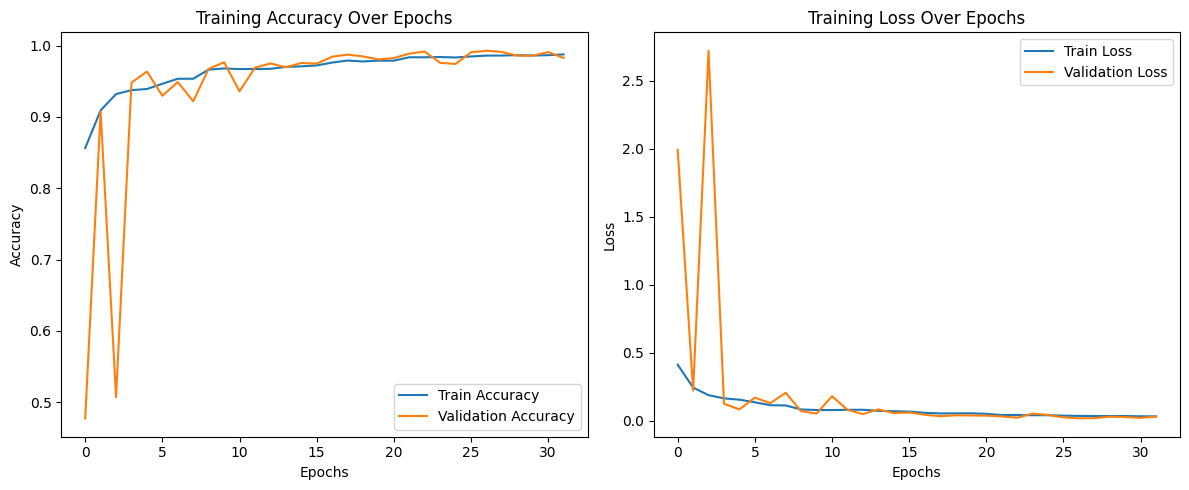

In [7]:
plot_training_history(history)

### Classification Metrics

265/265 [==============================] - 0s 1ms/step

Test Accuracy: 0.9928

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1789
           1     1.0000    1.0000    1.0000       188
           2     0.9509    0.9902    0.9701       508
           3     0.9615    0.9383    0.9498       373
           4     0.9954    0.9965    0.9960      2603
           5     1.0000    0.9897    0.9948      1938
           6     1.0000    0.9941    0.9971       511
           7     0.9238    0.9898    0.9557        98
           8     0.9978    1.0000    0.9989       463

    accuracy                         0.9928      8471
   macro avg     0.9810    0.9887    0.9847      8471
weighted avg     0.9929    0.9928    0.9928      8471



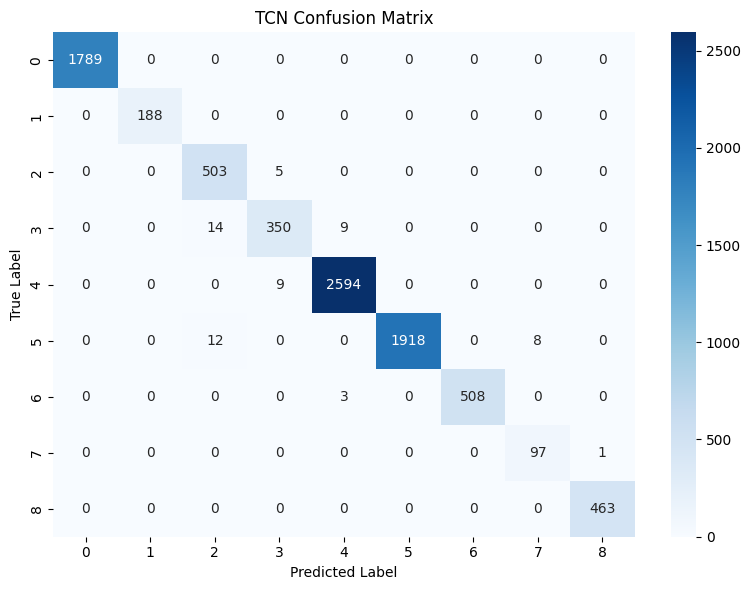

In [8]:
accuracy, report, y_pred = evaluate_classification(
    tcn_model,
    X_test,
    y_test
)

y_true = y_test.argmax(axis=1)

cm = plot_confusion_matrix(
    y_true,
    y_pred,
    title="TCN Confusion Matrix"
)

### Model Saving and Size Check

In [9]:
tcn_model.save("../../models/tcn_model.h5")

model_size = os.path.getsize("../../models/tcn_model.h5") / (1024 * 1024)
print(f"Real Model Size: {model_size:.2f} MB")

Real Model Size: 0.99 MB


/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## TinyML Performance

### TF Lite Conversion

In [10]:
TFLITE_MODEL_PATH = "../../models/tcn_model_quantized.tflite"

export_tflite_int8(
    model=tcn_model,
    X_calibration=X_train,
    save_path=TFLITE_MODEL_PATH,
    n_samples=200
)

INFO:tensorflow:Assets written to: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpnwfvw53k/assets


INFO:tensorflow:Assets written to: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpnwfvw53k/assets
/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-01 01:45:05.023668: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-01 01:45:05.023679: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-01 01:45:05.023840: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpnwfvw53k
2026-03-01 01:45:05.026150: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-01 01:45:05.026155: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/fold

Quantized model saved: ../../models/tcn_model_quantized.tflite (107.30 KB)


92949 microseconds.
2026-03-01 01:45:05.137486: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
Summary on the non-converted ops:
---------------------------------
 * Accepted dialects: tfl, builtin, func
 * Non-Converted Ops: 45, Total Ops 110, % non-converted = 40.91 %
 * 45 ARITH ops

- arith.constant:   45 occurrences  (f32: 33, i32: 12)



  (f32: 13)
  (f32: 4)
  (f32: 9)
  (f32: 9)
  (f32: 1)
  (f32: 1)
  (f32: 6)
  (f32: 6)
  (f32: 8)
  (f32: 1)
  (f32: 4)
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


b' \x00\x00\x00TFL3\x00\x00\x00\x00\x14\x00 \x00\x1c\x00\x18\x00\x14\x00\x10\x00\x0c\x00\x00\x00\x08\x00\x04\x00\x14\x00\x00\x00\x1c\x00\x00\x00\x80\x00\x00\x00\xd8\x00\x00\x008(\x01\x00H(\x01\x00\x04\xac\x01\x00\x03\x00\x00\x00\x01\x00\x00\x00\x04\x00\x00\x00~\xcc\xfe\xff\x0c\x00\x00\x00\x1c\x00\x00\x008\x00\x00\x00\x0f\x00\x00\x00serving_default\x00\x01\x00\x00\x00\x04\x00\x00\x00\x9c\xff\xff\xffn\x00\x00\x00\x04\x00\x00\x00\x05\x00\x00\x00dense\x00\x00\x00\x01\x00\x00\x00\x04\x00\x00\x00\xc6\xd6\xfe\xff\x04\x00\x00\x00\x07\x00\x00\x00input_1\x00\x02\x00\x00\x004\x00\x00\x00\x04\x00\x00\x00\xdc\xff\xff\xffq\x00\x00\x00\x04\x00\x00\x00\x13\x00\x00\x00CONVERSION_METADATA\x00\x08\x00\x0c\x00\x08\x00\x04\x00\x08\x00\x00\x00p\x00\x00\x00\x04\x00\x00\x00\x13\x00\x00\x00min_runtime_version\x00r\x00\x00\x00\\\'\x01\x00T\'\x01\x00,\'\x01\x00\x18\'\x01\x00\xfc&\x01\x00\xd4&\x01\x00\xc0&\x01\x00\xa8&\x01\x00\x8c&\x01\x00d&\x01\x00P&\x01\x008&\x01\x00\x1c&\x01\x00\x08&\x01\x00\xd4%\x01\x00\x84#\

### Evaluation

In [11]:
interpreter = load_tflite_model(TFLITE_MODEL_PATH)

y_pred = run_tflite_inference(interpreter, X_test)
y_true = np.argmax(y_test, axis=1)

print("TFLite model prediction completed.")

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


TFLite model prediction completed.


### Test Classification Report

In [12]:
accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

classification_rep = classification_report(y_true, y_pred, digits=4)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_rep)

Test Accuracy: 0.9386
Precision: 0.9485
Recall: 0.9386
F1-score: 0.9406

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1789
           1     0.8969    0.9255    0.9110       188
           2     0.8545    0.9941    0.9190       508
           3     0.9496    0.8579    0.9014       373
           4     0.9488    0.9689    0.9588      2603
           5     0.9965    0.8870    0.9386      1938
           6     0.9952    0.8160    0.8968       511
           7     0.5389    0.9898    0.6978        98
           8     0.7059    0.8812    0.7839       463

    accuracy                         0.9386      8471
   macro avg     0.8763    0.9245    0.8897      8471
weighted avg     0.9485    0.9386    0.9406      8471



### Confusion Matrix

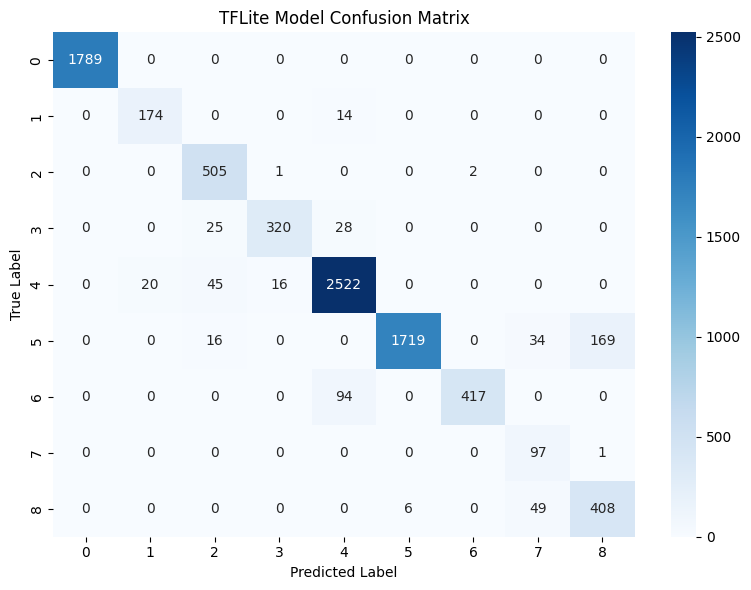

In [13]:
cm = plot_confusion_matrix(
    y_true,
    y_pred,
    title="TFLite Model Confusion Matrix"
)

### Model Size

In [14]:
tflite_model_path = "../../models/tcn_model_quantized.tflite"

tflite_model_size = os.path.getsize(tflite_model_path)

print(f"TFLite Model Size: {tflite_model_size / 1024:.2f} KB")

TFLite Model Size: 107.30 KB


### ESP32 Compatible Header File Creation

In [15]:
tflite_to_c_header(
    "../../models/tcn_model_quantized.tflite",
    var_name="tcn_model"
)

C header created: ../../models/tcn_model_quantized.h
Size: 107.30 KB


PosixPath('../../models/tcn_model_quantized.h')